In [1]:
import h5py
import numpy as np
import gvar as gv
import math
import lsqfit
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from scipy.special import kv, gamma
import inspect
#import warnings
#warnings.filterwarnings('ignore', category=RuntimeWarning)

# ---------------------------------------------------------
# 1. Jackknife Statistics Helper
# ---------------------------------------------------------
def Jackknife(datalist): 
    N = len(datalist)
    theta_bar = np.mean(datalist)
    theta_nminus_theta_bar = []
    for i in range(N): 
        theta_n = datalist[i]
        theta_nminus_theta_bar.append(np.square(theta_n - theta_bar))
    sigma_sq = ((N-1)/N) * np.sum(theta_nminus_theta_bar)
    return theta_bar, np.sqrt(sigma_sq)

def fmt_err(mean, err):
    # Fallback for 0 or negative error
    if err <= 0:
        return f"{mean}"
        
    # Switch to scientific if very small/big
    if mean and (abs(mean) < 1e-3 or abs(mean) >= 1e3):
        # Calculate exponent of the mean
        exp = int(math.floor(math.log10(abs(mean))))
        mean_scaled = mean / 10**exp
        err_scaled = err / 10**exp
        
        # Find precision needed for exactly 2 significant digits of the error
        place = int(math.floor(math.log10(abs(err_scaled))))
        ndec = max(0, -(place - 1))
        
        m_str = f"{mean_scaled:.{ndec}f}"
        err_int = int(round(err_scaled * 10**ndec))
        return f"{m_str}({err_int})e{exp}"
        
    else:
        # Find precision needed for exactly 2 significant digits of the error
        place = int(math.floor(math.log10(abs(err))))
        ndec = max(0, -(place - 1))  # -1 gives us 2 sig figs instead of 1
        
        m_str = f"{mean:.{ndec}f}"
        err_int = int(round(err * 10**ndec))
        return f"{m_str}({err_int})"


def load_params_from_h5(filename):
    fitted_params = {}
    with h5py.File(filename, "r") as f:
        # 1. Load the jackknifed parameter samples
        param_group = f["jackknife_samples"]
        for key in param_group.keys():
            # Read the dataset back into a numpy array
            fitted_params[key] = param_group[key][:]
            
        # 2. Load the chi-square per dof array
        chi2_dof_list = f["chi2_dof"][:]
        
    return fitted_params, chi2_dof_list


def print_latex_table(fitted_params, chi2_dof_list, PL, bmin, etamin, etamax):
    # Calculate jackknifed means and errors for all parameters
    res = {}
    for key in fitted_params:
        mean, err = Jackknife(fitted_params[key])
        res[key] = fmt_err(mean, err)
        
    mean_chi2, err_chi2 = Jackknife(chi2_dof_list)
    chi2_str = fmt_err(mean_chi2, err_chi2)

    # Group parameters by Amplitude
    # (Including 'f' since it's a shared parameter in your model)
    re_params = ['a_re', 'c_re', 'd_re', 'k1_re', 'k2_re', 'j_re', 'f']
    im_params = ['a_im', 'c_im', 'd_im', 'j_im', 'f']
    a12b_params = ['a_reA12B', 'c_reA12B', 'd_reA12B', 'j_reA12B', 'f']

    # Format values as comma-separated lists
    vals_re = ", ".join([res[p] for p in re_params])
    vals_im = ", ".join([res[p] for p in im_params])
    vals_a12b = ", ".join([res[p] for p in a12b_params])

    # LaTeX representations (Raw strings handle their own backslashes)
    eq_re = r"$\frac{a e^{-f \eta}}{\left[1 + \left(d + c\left(1 - \frac{k_1}{\eta} - \frac{k_2}{\eta^2}\right)\right) b_L^2 + d b_T^2\right]^j}$"
    eq_im = r"$\frac{a b_L e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$"
    eq_a12b = r"$\frac{-a e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$"

    names_re = r"$\{a, c, d, k_1, k_2, j, f\}$"
    names_im = r"$\{a, c, d, j, f\}$"
    names_a12b = r"$\{a, c, d, j, f\}$"

    # Construct Markdown string (Double backslashes used here to fix the escape sequence warnings)
    md = f"\n### Simultaneous Fit with common f: \n for PL={PL}, $b_{{min}} \\ge {bmin}$, $\\eta \\in [{etamin}, {etamax}]$\n\n $\\chi^2/\\text{{DoF}}$ = {chi2_str} (Global)\n\n"
    md += "| Amplitude | Model Expression | Params List | Fitted Values |\n"
    md += "| :--- | :--- | :--- | :--- |\n"
    md += f"| $\\text{{Re}}A_{{2B}}$ | {eq_re} | {names_re} | $[{vals_re}]$ |\n"
    md += f"| $\\text{{Im}}A_{{2B}}$ | {eq_im} | {names_im} | $[{vals_im}]$ |\n"
    md += f"| $\\text{{Re}}A_{{12B}}$ | {eq_a12b} | {names_a12b} | $[{vals_a12b}]$ |\n"

    # If running in Jupyter Notebook, render it nicely:
    try:
        from IPython.display import display, Markdown
        display(Markdown(md))
    except ImportError:
        # If running in a standard terminal, just print the markdown text
        print(md)


def plot_fourier_transforms_A2B_A12B(fitted_params, chi2_dof_list, b2, PL, bminfit, etamin, etamax, num_points=200):
    print_latex_table(fitted_params, chi2_dof_list, PL, bminfit, etamin, etamax)
    
    # Setup x-axis (avoid exactly 0 to prevent division by zero in Bessel/powers)
    x_vals = np.linspace(-1, 1, num_points)
    
    MassN = 0.6228
    lata = 0.11403
    massterm = MassN * (197 * 0.001 / lata)
    
    # 1. Extract parameters as NumPy arrays
    a_re = np.array(fitted_params['a_re'])
    c_re = np.array(fitted_params['c_re']) / (PL**2)
    d_re = 1.0 + np.array(fitted_params['d_re']) * b2  
    j_re = np.array(fitted_params['j_re'])

    a_im = np.array(fitted_params['a_im']) / PL
    c_im = np.array(fitted_params['c_im']) / (PL**2)
    d_im = 1.0 + np.array(fitted_params['d_im']) * b2
    j_im = np.array(fitted_params['j_im'])

    a_reA12B = -np.array(fitted_params['a_reA12B'])
    c_reA12B = np.array(fitted_params['c_reA12B']) / (PL**2)
    d_reA12B = 1.0 + np.array(fitted_params['d_reA12B']) * b2  
    j_reA12B = np.array(fitted_params['j_reA12B'])

    re_mean, re_err = [], []
    reA12B_mean, reA12B_err = [], []
    im_mean, im_err = [], []
    full_mean, full_err = [], []
    SiverseShift_mean, SiverseShift_err = [], []
    xSiverseShift_mean, xSiverseShift_err = [], []

    print("\nEvaluating Fourier transforms and applying Jackknife for Plotting...")
    
    # 3. Loop over each x value and apply your Jackknife function
    for x in x_vals:
        abs_x = np.abs(x)
        if abs_x == 0:  # Safeguard against zero in loop
            abs_x = 1e-12
            x = 1e-12

        # --- Evaluate Real Part ---
        cd_R = c_re / d_re
        term1_R = (2**(1 - j_re) * a_re * cd_R**(-0.25 - j_re/2) * d_re**(-j_re)) / gamma(j_re)
        term2_R = abs_x**(-0.5 + j_re)
        bessel_R = kv(0.5 - j_re, abs_x / np.sqrt(cd_R))
        
        re_evals_at_x = term1_R * term2_R * bessel_R
        m_re, e_re = Jackknife(re_evals_at_x)
        re_mean.append(m_re)
        re_err.append(e_re)

        # --- Evaluate Imaginary Part ---
        cd_I = c_im / d_im
        term1_I = (2**(1 - j_im) * a_im * cd_I**(0.25 * (-3 - 2*j_im)) * d_im**(-j_im)) / gamma(j_im)
        term2_I = x * abs_x**(-1.5 + j_im)
        bessel_I = kv(1.5 - j_im, np.sqrt(d_im / c_im) * abs_x)
        
        im_evals_at_x = term1_I * term2_I * bessel_I
        m_im, e_im = Jackknife(im_evals_at_x)
        im_mean.append(m_im)
        im_err.append(e_im)

        m_full, e_full = Jackknife(2*(re_evals_at_x-im_evals_at_x))
        full_mean.append(m_full)
        full_err.append(e_full)

        # --- Evaluate ReA12B Part ---
        cd_RA12B = c_reA12B / d_reA12B
        term1_RA12B = (2**(1 - j_reA12B) * a_reA12B * cd_RA12B**(-0.25 - j_reA12B/2) * d_reA12B**(-j_reA12B)) / gamma(j_reA12B)
        term2_RA12B = abs_x**(-0.5 + j_reA12B)
        bessel_RA12B = kv(0.5 - j_reA12B, abs_x / np.sqrt(cd_RA12B))
        
        reA12B_evals_at_x = term1_RA12B * term2_RA12B * bessel_RA12B
        
        m_reA12B, e_reA12B = Jackknife(-2*reA12B_evals_at_x)
        reA12B_mean.append(m_reA12B)
        reA12B_err.append(e_reA12B)

        m_SiverseShift, e_SiverseShift = Jackknife((-massterm*reA12B_evals_at_x)/(re_evals_at_x-im_evals_at_x))
        SiverseShift_mean.append(m_SiverseShift)
        SiverseShift_err.append(e_SiverseShift)

        m_xSiverseShift, e_xSiverseShift = Jackknife(x*(-massterm*reA12B_evals_at_x)/(re_evals_at_x-im_evals_at_x))
        xSiverseShift_mean.append(m_xSiverseShift)
        xSiverseShift_err.append(e_xSiverseShift)

    # Convert results to arrays for easier plotting
    re_mean, re_err = np.array(re_mean), np.array(re_err)
    im_mean, im_err = np.array(im_mean), np.array(im_err)
    full_mean, full_err = np.array(full_mean), np.array(full_err)
    reA12B_mean, reA12B_err = np.array(reA12B_mean), np.array(reA12B_err)
    SiverseShift_mean, SiverseShift_err = np.array(SiverseShift_mean), np.array(SiverseShift_err)
    xSiverseShift_mean, xSiverseShift_err = np.array(xSiverseShift_mean), np.array(xSiverseShift_err)

    # 4. Plotting
    fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(14, 8))

    # Real Plot
    ax1.plot(x_vals, re_mean, color='blue', label='ReA2B Mean')
    ax1.fill_between(x_vals, re_mean - re_err, re_mean + re_err, color='blue', alpha=0.3)
    ax1.set_title(f'$\\tilde{{A}}_{{2B}}^{{Re}}$ ($P_L$={PL}, $b^2$={b2})')
    ax1.set_xlabel('$x$')
    ax1.set_ylabel('$\\tilde{{A}}_{{2B}}^{{Re}}$')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Imaginary Plot
    ax2.plot(x_vals, im_mean, color='red', label='ImA2B Mean')
    ax2.fill_between(x_vals, im_mean - im_err, im_mean + im_err, color='red', alpha=0.3)
    ax2.set_title(f'$i\\tilde{{A}}_{{2B}}^{{Im}}$ ($P_L$={PL}, $b^2$={b2})')
    ax2.set_xlabel('$x$')
    ax2.set_ylabel('$i\\tilde{{A}}_{{2B}}^{{Im}}$')
    ax2.grid(True, linestyle='--', alpha=0.6)

    # Full f1 Plot
    ax3.plot(x_vals, full_mean, color='green', label='A2B Mean')
    ax3.fill_between(x_vals, full_mean - full_err, full_mean + full_err, color='green', alpha=0.3)
    ax3.set_title(f'$\\tilde{{f}}_{{1}}^{{(0)}}=2\\tilde{{A}}_{{2B}}$ ($P_L$={PL}, $b^2$={b2})')
    ax3.set_xlabel('$x$')
    ax3.set_ylabel('$\\tilde{{f}}_{{1}}^{{(0)}}$')
    ax3.grid(True, linestyle='--', alpha=0.6)

    # A12B Plot
    ax4.plot(x_vals, reA12B_mean, color='blue')
    ax4.fill_between(x_vals, reA12B_mean - reA12B_err, reA12B_mean + reA12B_err, color='blue', alpha=0.3)
    ax4.set_title(f'$\\tilde{{f}}_{{1}}^{{\\perp(1)}}=-2\\tilde{{A}}_{{12B}}$ ($P_L$={PL}, $b^2$={b2})')
    ax4.set_xlabel('$x$')
    ax4.set_ylabel('$\\tilde{{f}}_{{1}}^{{\\perp(1)}}$')
    ax4.grid(True, linestyle='--', alpha=0.6)
    
    # Create mask for x values from 0 to 1
    mask = x_vals >= 0

    # Sivers Shift Plot (0 to 1)
    ax5.plot(x_vals[mask], SiverseShift_mean[mask], color='blue')
    ax5.fill_between(x_vals[mask], SiverseShift_mean[mask] - SiverseShift_err[mask], 
                     SiverseShift_mean[mask] + SiverseShift_err[mask], color='blue', alpha=0.3)
    ax5.set_title(f'$\\langle k_{{y}} \\rangle_{{TU}}$(GeV) ($P_L$={PL}, $b^2$={b2})')
    ax5.set_xlabel('$x$')
    ax5.set_ylabel('$\\langle k_{{y}} \\rangle_{{TU}}$(GeV)')
    ax5.grid(True, linestyle='--', alpha=0.6)

    # x*Sivers Shift Plot (0 to 1)
    ax6.plot(x_vals[mask], xSiverseShift_mean[mask], color='blue')
    ax6.fill_between(x_vals[mask], xSiverseShift_mean[mask] - xSiverseShift_err[mask], 
                     xSiverseShift_mean[mask] + xSiverseShift_err[mask], color='blue', alpha=0.3)
    ax6.set_title(f'$x\\langle k_{{y}} \\rangle_{{TU}}$(GeV) ($P_L$={PL}, $b^2$={b2})')
    ax6.set_xlabel('$x$')
    ax6.set_ylabel('$x\\langle k_{{y}} \\rangle_{{TU}}$(GeV)')
    ax6.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    param_keys_str = "-".join(fitted_params.keys())
    file_name = f"SimulFitCovMatrix-A12B-A2B-FT-{param_keys_str}__bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.pdf"
    plt.savefig(file_name, format='pdf', bbox_inches='tight')
    plt.show()

    return



### Simultaneous Fit with common f: 
 for PL=-1, $b_{min} \ge 3$, $\eta \in [6, 10]$

 $\chi^2/\text{DoF}$ = 1.85(10) (Global)

| Amplitude | Model Expression | Params List | Fitted Values |
| :--- | :--- | :--- | :--- |
| $\text{Re}A_{2B}$ | $\frac{a e^{-f \eta}}{\left[1 + \left(d + c\left(1 - \frac{k_1}{\eta} - \frac{k_2}{\eta^2}\right)\right) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, k_1, k_2, j, f\}$ | $[3.863(11), 0.336(40), 0.1630(74), 12.288(23), -36.1965(45), 1.627(25), 0.4702(46)]$ |
| $\text{Im}A_{2B}$ | $\frac{a b_L e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, j, f\}$ | $[0.267(13), 0.2253(69), 0.2205(66), 1.108(21), 0.4702(46)]$ |
| $\text{Re}A_{12B}$ | $\frac{-a e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, j, f\}$ | $[0.658(22), 0.0773(46), 0.0747(43), 2.0054(90), 0.4702(46)]$ |



Evaluating Fourier transforms and applying Jackknife for Plotting...


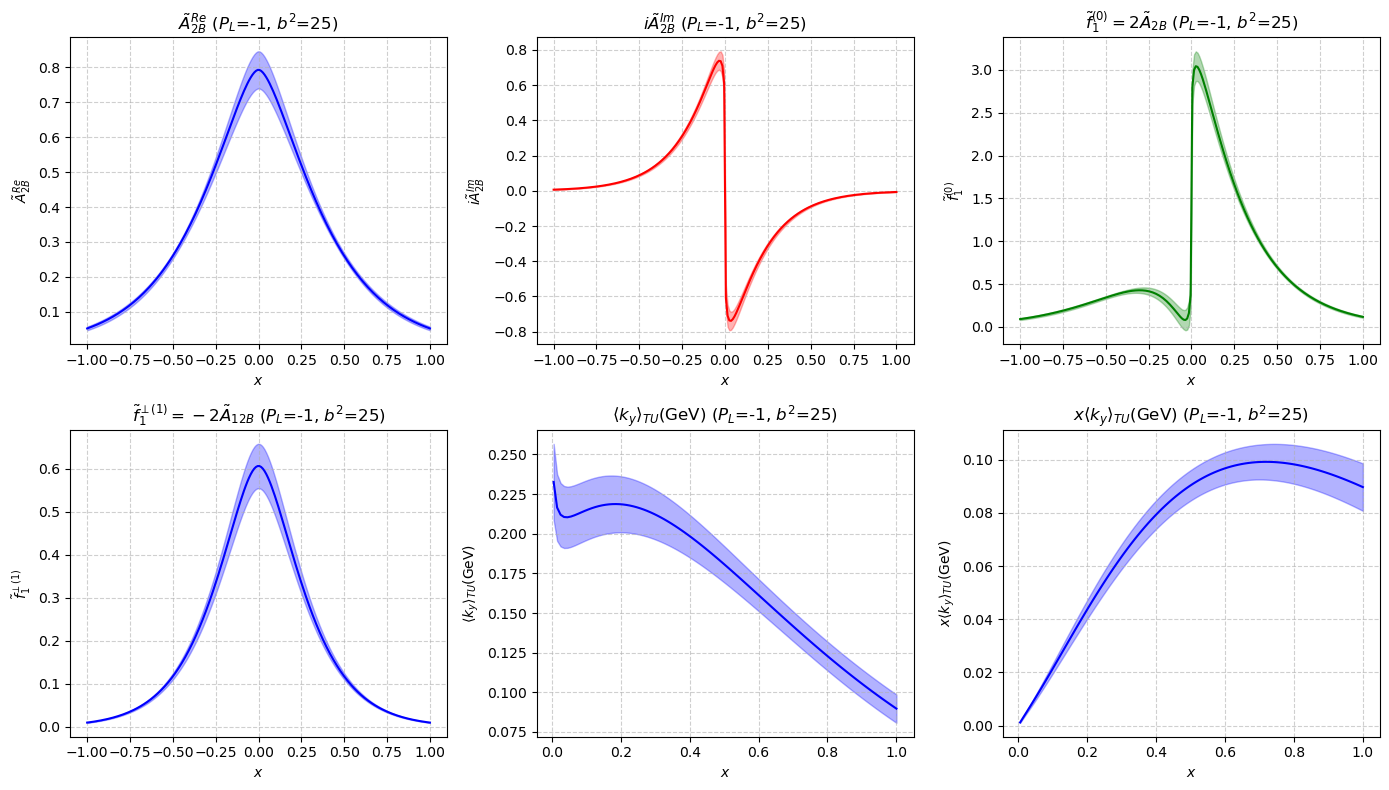

In [4]:
b2 = 25
PL = -1
bminfit = 3
etamin = 6
etamax = 10
#sivers_TMD_PhD_project/save_h5_A12B_A2B/SimultaniousFit/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin3_eta610_PL-4.h5
fitted_params, chi2_dof_list = load_params_from_h5(f"/Users/hariprashadravikumar/sivers_TMD_PhD_project/save_h5_A12B_A2B/SimultaniousFit/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.h5")
plot_fourier_transforms_A2B_A12B(fitted_params, chi2_dof_list, b2, PL, bminfit, etamin, etamax)


In [40]:
import h5py
import numpy as np
import gvar as gv
import math
import lsqfit
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from scipy.special import kv, gamma
import inspect

# ---------------------------------------------------------
# 1. Jackknife Statistics Helper
# ---------------------------------------------------------
def Jackknife(datalist): 
    N = len(datalist)
    theta_bar = np.mean(datalist)
    theta_nminus_theta_bar = []
    for i in range(N): 
        theta_n = datalist[i]
        theta_nminus_theta_bar.append(np.square(theta_n - theta_bar))
    sigma_sq = ((N-1)/N) * np.sum(theta_nminus_theta_bar)
    return theta_bar, np.sqrt(sigma_sq)

def fmt_err(mean, err):
    # Fallback for 0 or negative error
    if err <= 0:
        return f"{mean}"
        
    # Switch to scientific if very small/big
    if mean and (abs(mean) < 1e-3 or abs(mean) >= 1e3):
        # Calculate exponent of the mean
        exp = int(math.floor(math.log10(abs(mean))))
        mean_scaled = mean / 10**exp
        err_scaled = err / 10**exp
        
        # Find precision needed for exactly 2 significant digits of the error
        place = int(math.floor(math.log10(abs(err_scaled))))
        ndec = max(0, -(place - 1))
        
        m_str = f"{mean_scaled:.{ndec}f}"
        err_int = int(round(err_scaled * 10**ndec))
        return f"{m_str}({err_int})e{exp}"
        
    else:
        # Find precision needed for exactly 2 significant digits of the error
        place = int(math.floor(math.log10(abs(err))))
        ndec = max(0, -(place - 1))  # -1 gives us 2 sig figs instead of 1
        
        m_str = f"{mean:.{ndec}f}"
        err_int = int(round(err * 10**ndec))
        return f"{m_str}({err_int})"

def load_params_from_h5(filename):
    fitted_params = {}
    with h5py.File(filename, "r") as f:
        # 1. Load the jackknifed parameter samples
        param_group = f["jackknife_samples"]
        for key in param_group.keys():
            # Read the dataset back into a numpy array
            fitted_params[key] = param_group[key][:]
            
        # 2. Load the chi-square per dof array
        chi2_dof_list = f["chi2_dof"][:]
        
    return fitted_params, chi2_dof_list

def print_latex_table(fitted_params, chi2_dof_list, PL, bmin, etamin, etamax):
    # Calculate jackknifed means and errors for all parameters
    res = {}
    for key in fitted_params:
        mean, err = Jackknife(fitted_params[key])
        res[key] = fmt_err(mean, err)
        
    mean_chi2, err_chi2 = Jackknife(chi2_dof_list)
    chi2_str = fmt_err(mean_chi2, err_chi2)

    # Group parameters by Amplitude
    # (Including 'f' since it's a shared parameter in your model)
    re_params = ['a_re', 'c_re', 'd_re', 'k1_re', 'k2_re', 'j_re', 'f']
    im_params = ['a_im', 'c_im', 'd_im', 'j_im', 'f']
    a12b_params = ['a_reA12B', 'c_reA12B', 'd_reA12B', 'j_reA12B', 'f']

    # Format values as comma-separated lists
    vals_re = ", ".join([res.get(p, "N/A") for p in re_params])
    vals_im = ", ".join([res.get(p, "N/A") for p in im_params])
    vals_a12b = ", ".join([res.get(p, "N/A") for p in a12b_params])

    # LaTeX representations
    eq_re = r"$\frac{a e^{-f \eta}}{\left[1 + \left(d + c\left(1 - \frac{k_1}{\eta} - \frac{k_2}{\eta^2}\right)\right) b_L^2 + d b_T^2\right]^j}$"
    eq_im = r"$\frac{a b_L e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$"
    eq_a12b = r"$\frac{-a e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$"

    names_re = r"$\{a, c, d, k_1, k_2, j, f\}$"
    names_im = r"$\{a, c, d, j, f\}$"
    names_a12b = r"$\{a, c, d, j, f\}$"

    md = f"\n### Simultaneous Fit with common f: \n for PL={PL}, $b_{{min}} \\ge {bmin}$, $\\eta \\in [{etamin}, {etamax}]$\n\n $\\chi^2/\\text{{DoF}}$ = {chi2_str} (Global)\n\n"
    md += "| Amplitude | Model Expression | Params List | Fitted Values |\n"
    md += "| :--- | :--- | :--- | :--- |\n"
    md += f"| $\\text{{Re}}A_{{2B}}$ | {eq_re} | {names_re} | $[{vals_re}]$ |\n"
    md += f"| $\\text{{Im}}A_{{2B}}$ | {eq_im} | {names_im} | $[{vals_im}]$ |\n"
    md += f"| $\\text{{Re}}A_{{12B}}$ | {eq_a12b} | {names_a12b} | $[{vals_a12b}]$ |\n"

    try:
        from IPython.display import display, Markdown
        display(Markdown(md))
    except ImportError:
        print(md)

def plot_fourier_transforms_3D(fitted_params, chi2_dof_list, PL, bminfit, etamin, etamax, num_points_x=100, num_points_b2=40):
    print_latex_table(fitted_params, chi2_dof_list, PL, bminfit, etamin, etamax)
    
    # 1. Setup Grids for x and b^2
    x_vals = np.linspace(-1, 1, num_points_x)
    b2_vals = np.linspace(9, 68, num_points_b2)
    X, B2 = np.meshgrid(x_vals, b2_vals)
    
    MassN = 0.6228
    lata = 0.11403
    massterm = MassN * (197 * 0.001 / lata)
    
    # Extract independent parameters
    a_re = np.array(fitted_params['a_re'])
    c_re = np.array(fitted_params['c_re']) / (PL**2)
    j_re = np.array(fitted_params['j_re'])

    a_im = np.array(fitted_params['a_im']) / PL
    c_im = np.array(fitted_params['c_im']) / (PL**2)
    j_im = np.array(fitted_params['j_im'])

    a_reA12B = -np.array(fitted_params['a_reA12B'])
    c_reA12B = np.array(fitted_params['c_reA12B']) / (PL**2)
    j_reA12B = np.array(fitted_params['j_reA12B'])
    
    # Initialize 2D arrays to store means and errors
    shape = X.shape
    re_mean_2d, re_err_2d = np.zeros(shape), np.zeros(shape)
    im_mean_2d, im_err_2d = np.zeros(shape), np.zeros(shape)
    full_mean_2d, full_err_2d = np.zeros(shape), np.zeros(shape)
    reA12B_mean_2d, reA12B_err_2d = np.zeros(shape), np.zeros(shape)
    SiverseShift_mean_2d, SiverseShift_err_2d = np.zeros(shape), np.zeros(shape)
    xSiverseShift_mean_2d, xSiverseShift_err_2d = np.zeros(shape), np.zeros(shape)

    print("\nEvaluating Fourier transforms and applying Jackknife for 3D Plotting...")
    
    # Loop over b2 (rows of meshgrid) and x (cols of meshgrid)
    for i, b2 in enumerate(tqdm(b2_vals, desc="Evaluating over b^2 grid")):
        # d parameters depend on the current b^2 value
        d_re = 1.0 + np.array(fitted_params['d_re']) * b2  
        d_im = 1.0 + np.array(fitted_params['d_im']) * b2
        d_reA12B = 1.0 + np.array(fitted_params['d_reA12B']) * b2
        
        for j, x in enumerate(x_vals):
            abs_x = np.abs(x)
            if abs_x == 0: 
                abs_x = 1e-12
                x = 1e-12

            # --- Evaluate Real Part ---
            cd_R = c_re / d_re
            term1_R = (2**(1 - j_re) * a_re * cd_R**(-0.25 - j_re/2) * d_re**(-j_re)) / gamma(j_re)
            term2_R = abs_x**(-0.5 + j_re)
            bessel_R = kv(0.5 - j_re, abs_x / np.sqrt(cd_R))
            
            re_evals_at_x = term1_R * term2_R * bessel_R
            re_mean_2d[i, j], re_err_2d[i, j] = Jackknife(re_evals_at_x)

            # --- Evaluate Imaginary Part ---
            cd_I = c_im / d_im
            term1_I = (2**(1 - j_im) * a_im * cd_I**(0.25 * (-3 - 2*j_im)) * d_im**(-j_im)) / gamma(j_im)
            term2_I = x * abs_x**(-1.5 + j_im)
            bessel_I = kv(1.5 - j_im, np.sqrt(d_im / c_im) * abs_x)
            
            im_evals_at_x = term1_I * term2_I * bessel_I
            im_mean_2d[i, j], im_err_2d[i, j] = Jackknife(im_evals_at_x)

            # --- Full A2B ---
            full_mean_2d[i, j], full_err_2d[i, j] = Jackknife(2*(re_evals_at_x - im_evals_at_x))

            # --- Evaluate ReA12B Part ---
            cd_RA12B = c_reA12B / d_reA12B
            term1_RA12B = (2**(1 - j_reA12B) * a_reA12B * cd_RA12B**(-0.25 - j_reA12B/2) * d_reA12B**(-j_reA12B)) / gamma(j_reA12B)
            term2_RA12B = abs_x**(-0.5 + j_reA12B)
            bessel_RA12B = kv(0.5 - j_reA12B, abs_x / np.sqrt(cd_RA12B))
            
            reA12B_evals_at_x = term1_RA12B * term2_RA12B * bessel_RA12B
            
            reA12B_mean_2d[i, j], reA12B_err_2d[i, j] = Jackknife(-2*reA12B_evals_at_x)

            # --- Sivers Shift ---
            m_SiverseShift, e_SiverseShift = Jackknife((-massterm*reA12B_evals_at_x)/(re_evals_at_x - im_evals_at_x))
            SiverseShift_mean_2d[i, j] = m_SiverseShift
            SiverseShift_err_2d[i, j] = e_SiverseShift

            # --- x * Sivers Shift ---
            m_xSiverseShift, e_xSiverseShift = Jackknife(x*(-massterm*reA12B_evals_at_x)/(re_evals_at_x - im_evals_at_x))
            xSiverseShift_mean_2d[i, j] = m_xSiverseShift
            xSiverseShift_err_2d[i, j] = e_xSiverseShift

    # 4. Plotting in 3D
    fig = plt.figure(figsize=(18, 12))

    # Helper function to plot 3D mean + error bands
    def plot_3d_band(ax, X_grid, Y_grid, Z_mean, Z_err, color_val, title_val, ylabel_val):
        # Mean Surface
        ax.plot_surface(X_grid, Y_grid, Z_mean, color=color_val, alpha=0.7, edgecolor='none')
        # Upper Error Surface
        ax.plot_surface(X_grid, Y_grid, Z_mean + Z_err, color=color_val, alpha=0.2, edgecolor='none')
        # Lower Error Surface
        ax.plot_surface(X_grid, Y_grid, Z_mean - Z_err, color=color_val, alpha=0.2, edgecolor='none')
        
        ax.set_title(title_val)
        ax.set_xlabel('$x$')
        ax.set_ylabel('$b^2$')
        ax.set_zlabel(ylabel_val)

    # 1. Real Plot
    ax1 = fig.add_subplot(231, projection='3d')
    plot_3d_band(ax1, X, B2, re_mean_2d, re_err_2d, 'blue', f'$\\tilde{{A}}_{{2B}}^{{Re}}$ ($P_L$={PL})', '$\\tilde{{A}}_{{2B}}^{{Re}}$')

    # 2. Imaginary Plot
    ax2 = fig.add_subplot(232, projection='3d')
    plot_3d_band(ax2, X, B2, im_mean_2d, im_err_2d, 'red', f'$i\\tilde{{A}}_{{2B}}^{{Im}}$ ($P_L$={PL})', '$i\\tilde{{A}}_{{2B}}^{{Im}}$')

    # 3. Full f1 Plot
    ax3 = fig.add_subplot(233, projection='3d')
    plot_3d_band(ax3, X, B2, full_mean_2d, full_err_2d, 'purple', f'$\\tilde{{f}}_{{1}}^{{(0)}}=2\\tilde{{A}}_{{2B}}$ ($P_L$={PL})', '$\\tilde{{f}}_{{1}}^{{(0)}}$')

    # 4. A12B Plot
    ax4 = fig.add_subplot(234, projection='3d')
    plot_3d_band(ax4, X, B2, reA12B_mean_2d, reA12B_err_2d, 'green', f'$\\tilde{{f}}_{{1}}^{{\\perp(1)}}=-2\\tilde{{A}}_{{12B}}$ ($P_L$={PL})', '$\\tilde{{f}}_{{1}}^{{\\perp(1)}}$')

    # Create masks and sub-grids for x >= 0 (plots 5 and 6)
    mask_idx = np.where(x_vals >= 0)[0]
    x_vals_pos = x_vals[mask_idx]
    X_pos, B2_pos = np.meshgrid(x_vals_pos, b2_vals)
    
    SiverseShift_mean_pos = SiverseShift_mean_2d[:, mask_idx]
    SiverseShift_err_pos = SiverseShift_err_2d[:, mask_idx]
    
    xSiverseShift_mean_pos = xSiverseShift_mean_2d[:, mask_idx]
    xSiverseShift_err_pos = xSiverseShift_err_2d[:, mask_idx]

    # 5. Sivers Shift Plot (0 to 1)
    ax5 = fig.add_subplot(235, projection='3d')
    plot_3d_band(ax5, X_pos, B2_pos, SiverseShift_mean_pos, SiverseShift_err_pos, 'olive', 
                 f'$\\langle k_{{y}} \\rangle_{{TU}}$(GeV) ($P_L$={PL})', '$\\langle k_{{y}} \\rangle_{{TU}}$(GeV)')

    # 6. x*Sivers Shift Plot (0 to 1)
    ax6 = fig.add_subplot(236, projection='3d')
    plot_3d_band(ax6, X_pos, B2_pos, xSiverseShift_mean_pos, xSiverseShift_err_pos, 'olive', 
                 f'$x\\langle k_{{y}} \\rangle_{{TU}}$(GeV) ($P_L$={PL})', '$x\\langle k_{{y}} \\rangle_{{TU}}$(GeV)')

    plt.tight_layout()
    param_keys_str = "-".join(fitted_params.keys())
    file_name = f"SimulFitCovMatrix-A12B-A2B-FT-3D_{param_keys_str}__bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.pdf"
    plt.savefig(file_name, format='pdf', bbox_inches='tight')
    plt.show()

# Example execution call (replace with your variables)
# plot_fourier_transforms_3D(fitted_params, chi2_dof_list, PL=..., bminfit=..., etamin=..., etamax=...)


### Simultaneous Fit with common f: 
 for PL=-1, $b_{min} \ge 3$, $\eta \in [6, 10]$

 $\chi^2/\text{DoF}$ = 1.85(10) (Global)

| Amplitude | Model Expression | Params List | Fitted Values |
| :--- | :--- | :--- | :--- |
| $\text{Re}A_{2B}$ | $\frac{a e^{-f \eta}}{\left[1 + \left(d + c\left(1 - \frac{k_1}{\eta} - \frac{k_2}{\eta^2}\right)\right) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, k_1, k_2, j, f\}$ | $[3.863(11), 0.336(40), 0.1630(74), 12.288(23), -36.1965(45), 1.627(25), 0.4702(46)]$ |
| $\text{Im}A_{2B}$ | $\frac{a b_L e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, j, f\}$ | $[0.267(13), 0.2253(69), 0.2205(66), 1.108(21), 0.4702(46)]$ |
| $\text{Re}A_{12B}$ | $\frac{-a e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, j, f\}$ | $[0.658(22), 0.0773(46), 0.0747(43), 2.0054(90), 0.4702(46)]$ |



Evaluating Fourier transforms and applying Jackknife for 3D Plotting...


Evaluating over b^2 grid:   0%|          | 0/40 [00:00<?, ?it/s]

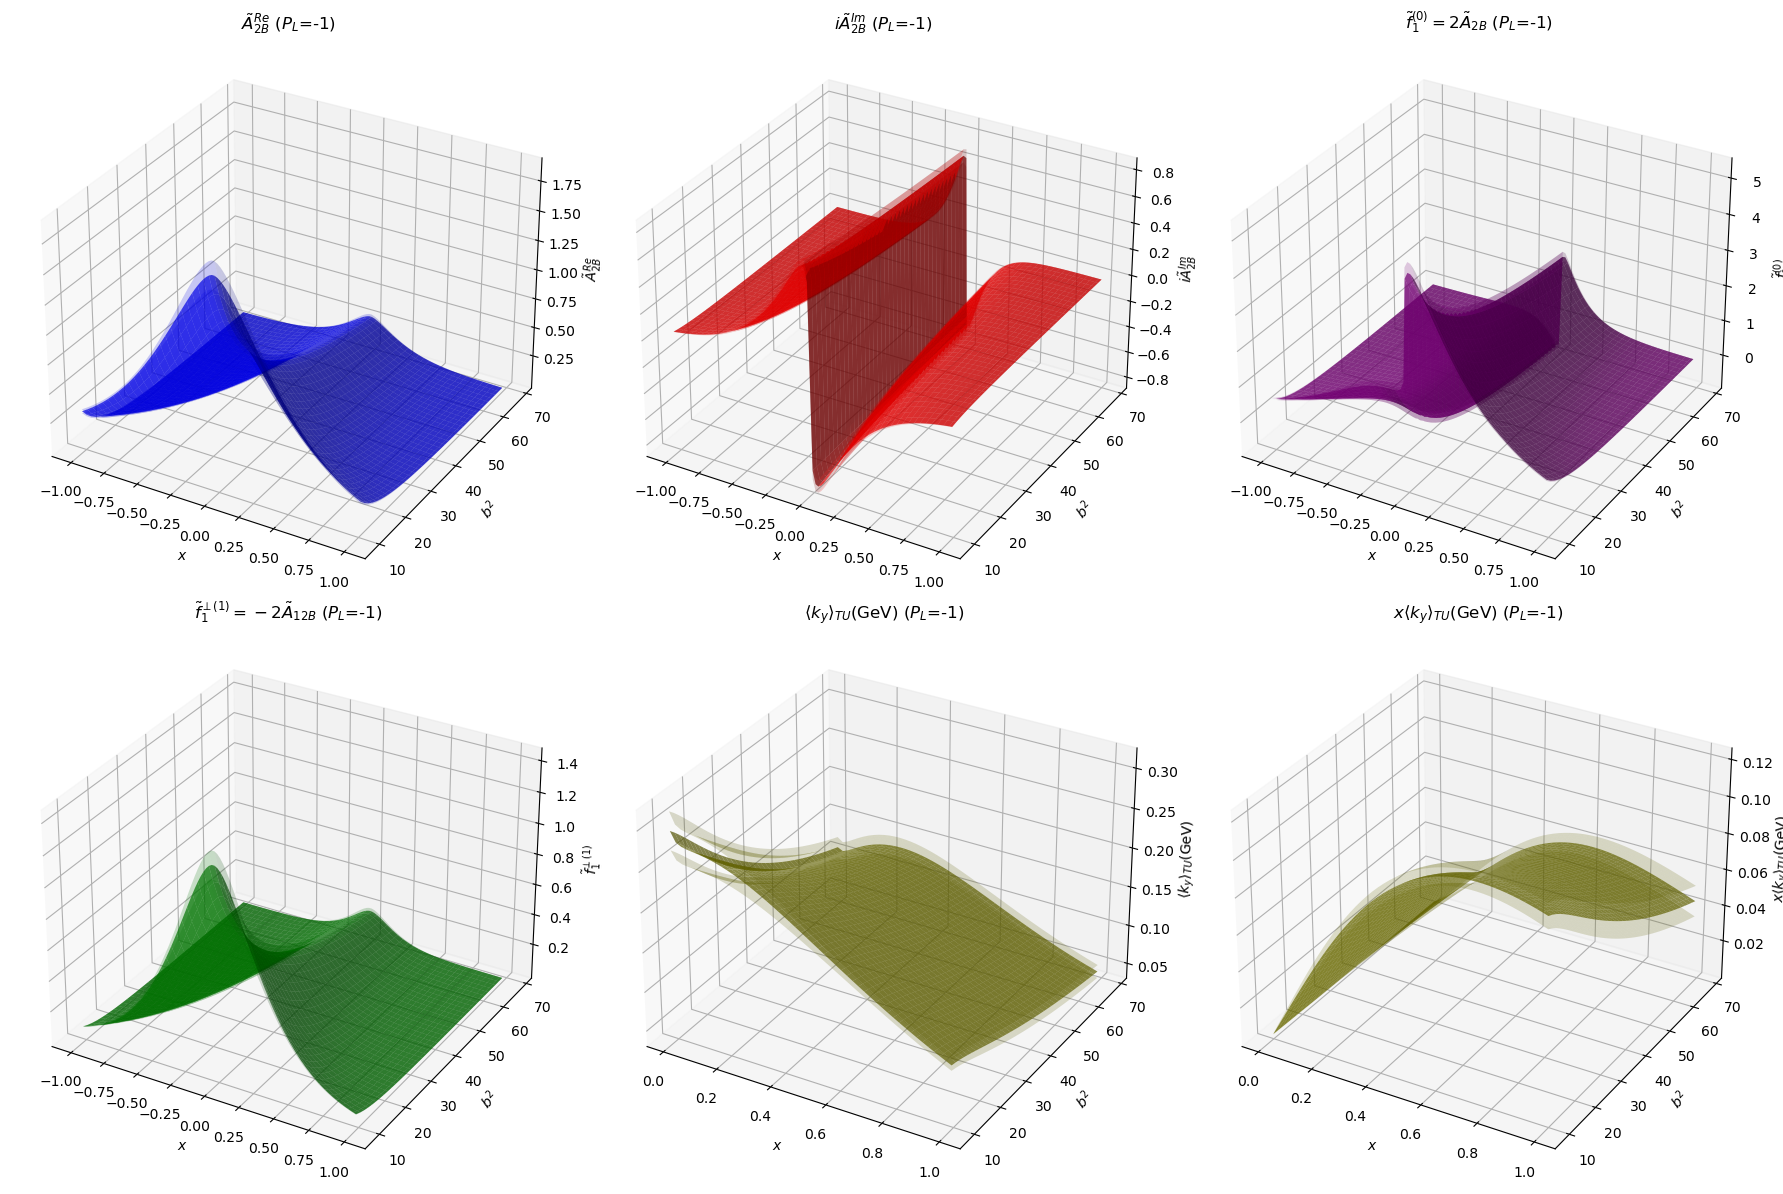

In [44]:
b2 = 9
PL = -1
bminfit = 3
etamin = 6
etamax = 10
#sivers_TMD_PhD_project/save_h5_A12B_A2B/SimultaniousFit/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin3_eta610_PL-4.h5
fitted_params, chi2_dof_list = load_params_from_h5(f"/Users/hariprashadravikumar/sivers_TMD_PhD_project/save_h5_A12B_A2B/SimultaniousFit/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.h5")
plot_fourier_transforms_3D(fitted_params, chi2_dof_list, PL, bminfit, etamin, etamax)



### Simultaneous Fit with common f: 
 for PL=-2, $b_{min} \ge 3$, $\eta \in [6, 10]$

 $\chi^2/\text{DoF}$ = 1.197(85) (Global)

| Amplitude | Model Expression | Params List | Fitted Values |
| :--- | :--- | :--- | :--- |
| $\text{Re}A_{2B}$ | $\frac{a e^{-f \eta}}{\left[1 + \left(d + c\left(1 - \frac{k_1}{\eta} - \frac{k_2}{\eta^2}\right)\right) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, k_1, k_2, j, f\}$ | $[3.9833(80), 0.166(35), 0.1020(46), 12.305(14), -36.1919(27), 2.061(20), 0.5357(66)]$ |
| $\text{Im}A_{2B}$ | $\frac{a b_L e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, j, f\}$ | $[0.368(12), 0.1346(69), 0.1305(67), 1.141(20), 0.5357(66)]$ |
| $\text{Re}A_{12B}$ | $\frac{-a e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, j, f\}$ | $[0.632(19), 0.0769(54), 0.0741(52), 2.0141(69), 0.5357(66)]$ |



Evaluating Fourier transforms and applying Jackknife for 3D Plotting...


Evaluating over b^2 grid:   0%|          | 0/40 [00:00<?, ?it/s]

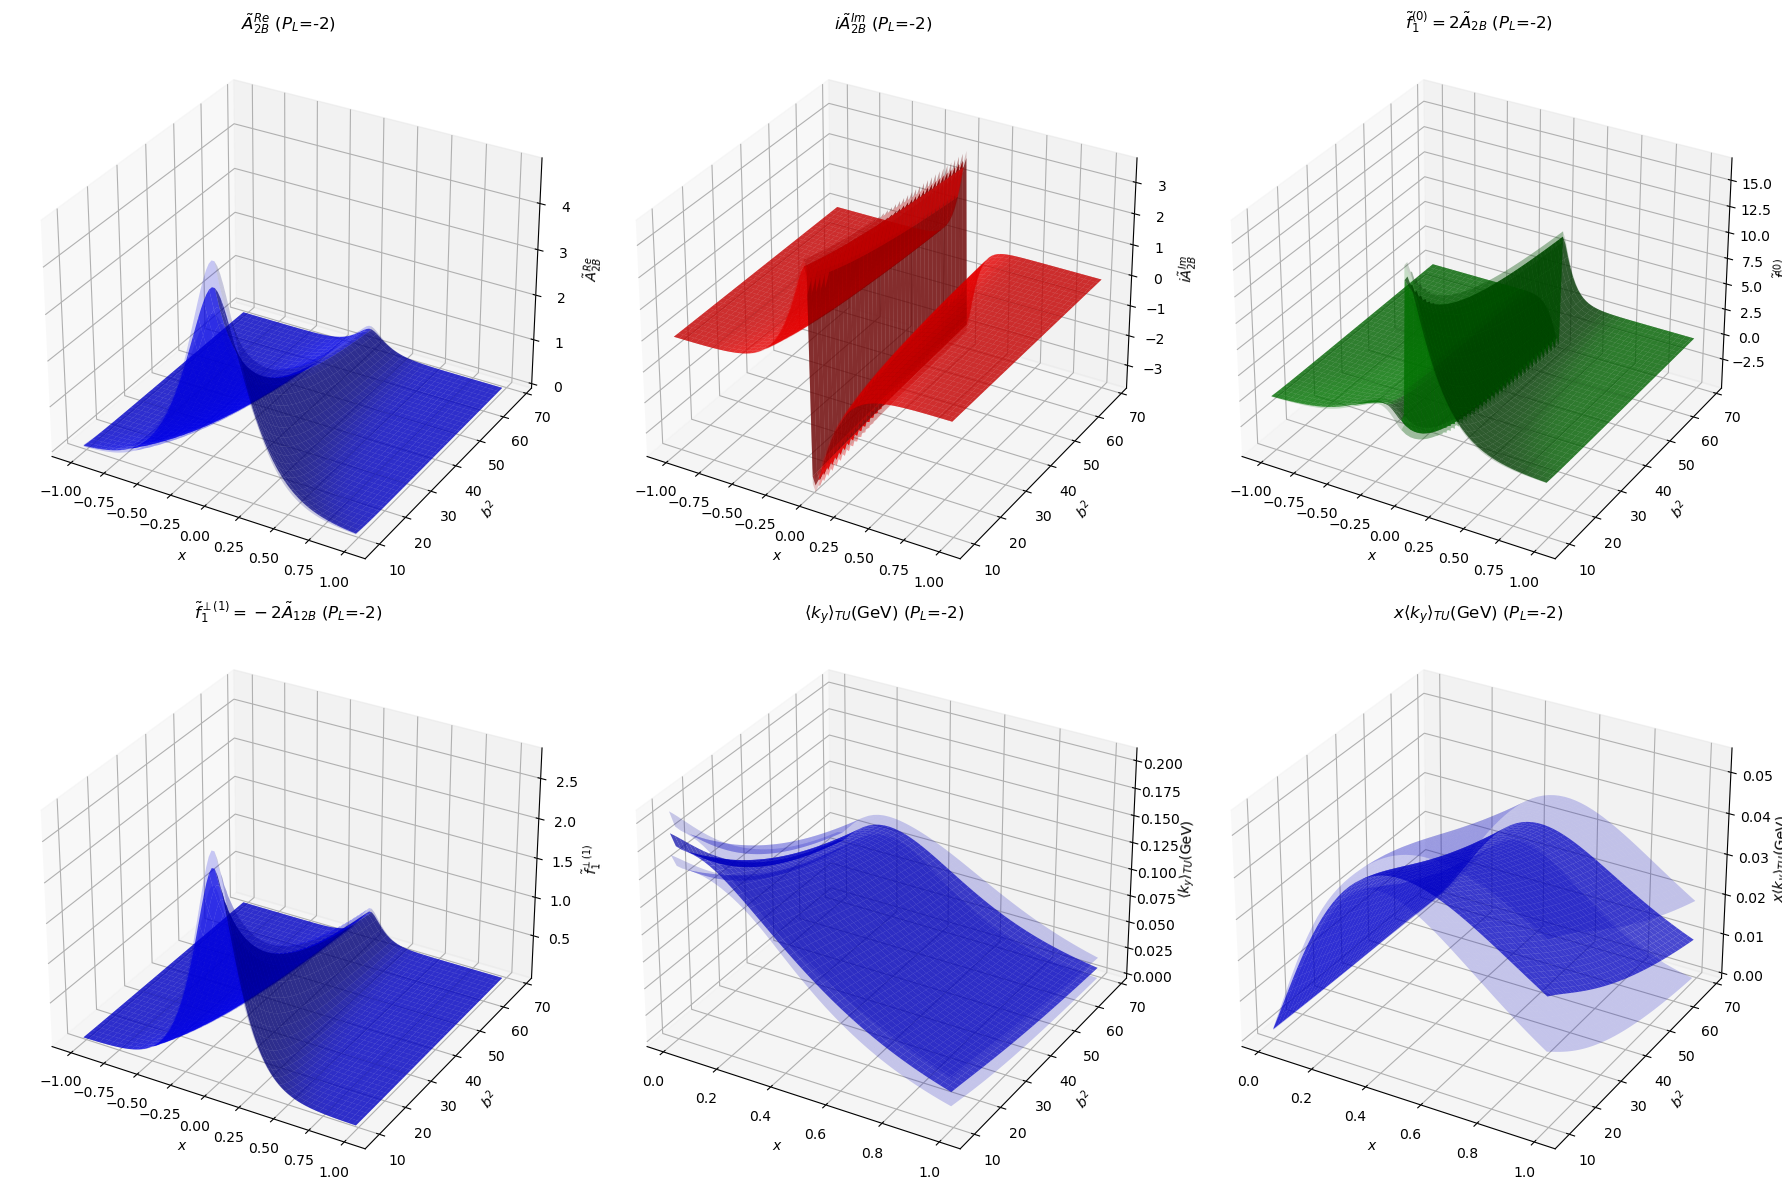

In [12]:
PL = -2
bminfit = 3
etamin = 6
etamax = 10
#sivers_TMD_PhD_project/save_h5_A12B_A2B/SimultaniousFit/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin3_eta610_PL-4.h5
fitted_params, chi2_dof_list = load_params_from_h5(f"/Users/hariprashadravikumar/sivers_TMD_PhD_project/save_h5_A12B_A2B/SimultaniousFit/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.h5")
plot_fourier_transforms_3D(fitted_params, chi2_dof_list, PL, bminfit, etamin, etamax)



### Simultaneous Fit with common f: 
 for PL=-3, $b_{min} \ge 3$, $\eta \in [6, 10]$

 $\chi^2/\text{DoF}$ = 0.712(66) (Global)

| Amplitude | Model Expression | Params List | Fitted Values |
| :--- | :--- | :--- | :--- |
| $\text{Re}A_{2B}$ | $\frac{a e^{-f \eta}}{\left[1 + \left(d + c\left(1 - \frac{k_1}{\eta} - \frac{k_2}{\eta^2}\right)\right) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, k_1, k_2, j, f\}$ | $[4.0061(31), 0.45(12), 0.136(11), 12.284(11), -36.1973(19), 2.085(10), 0.540(15)]$ |
| $\text{Im}A_{2B}$ | $\frac{a b_L e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, j, f\}$ | $[0.328(11), 0.163(15), 0.147(13), 1.057(15), 0.540(15)]$ |
| $\text{Re}A_{12B}$ | $\frac{-a e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, j, f\}$ | $[0.569(13), 0.100(17), 0.094(16), 1.9969(49), 0.540(15)]$ |



Evaluating Fourier transforms and applying Jackknife for 3D Plotting...


Evaluating over b^2 grid:   0%|          | 0/40 [00:00<?, ?it/s]

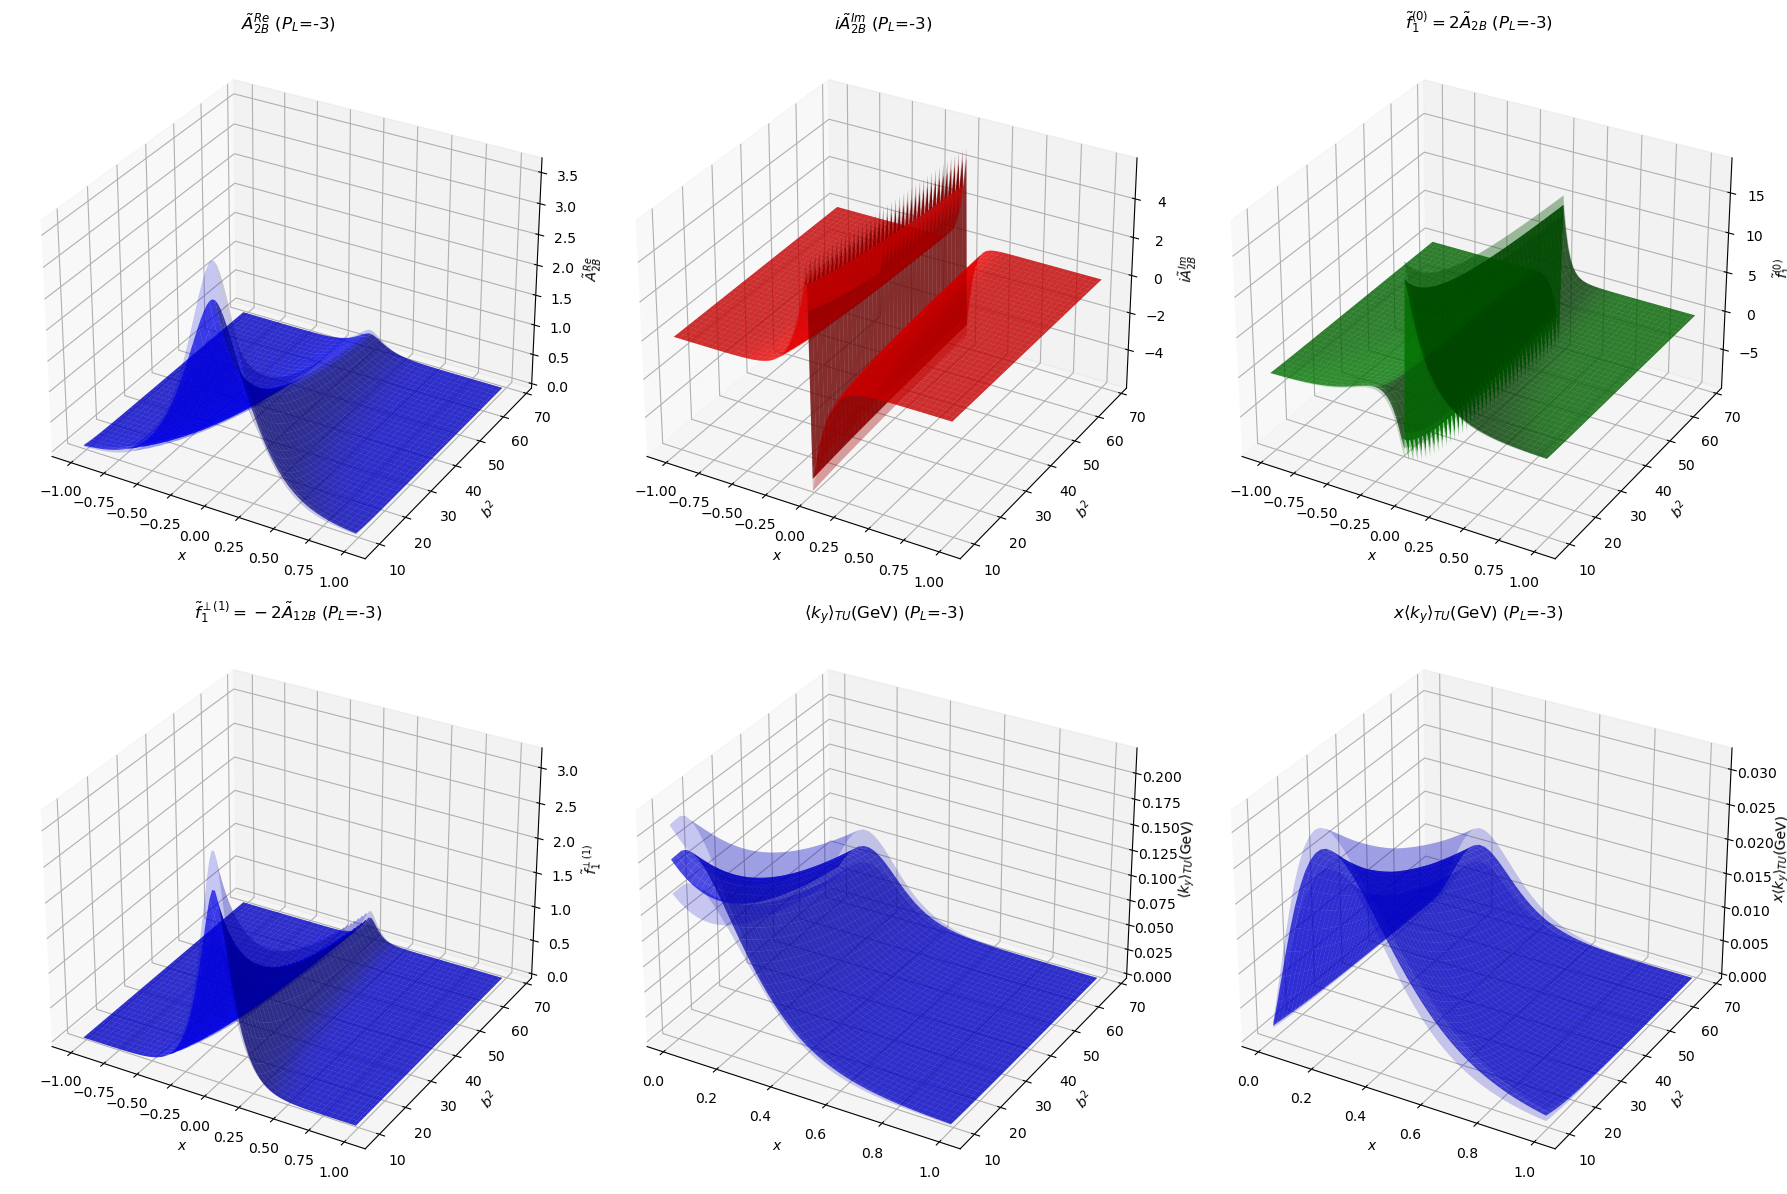

In [13]:
PL = -3
bminfit = 3
etamin = 6
etamax = 10
#sivers_TMD_PhD_project/save_h5_A12B_A2B/SimultaniousFit/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin3_eta610_PL-4.h5
fitted_params, chi2_dof_list = load_params_from_h5(f"/Users/hariprashadravikumar/sivers_TMD_PhD_project/save_h5_A12B_A2B/SimultaniousFit/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.h5")
plot_fourier_transforms_3D(fitted_params, chi2_dof_list, PL, bminfit, etamin, etamax)



### Simultaneous Fit with common f: 
 for PL=-4, $b_{min} \ge 3$, $\eta \in [6, 10]$

 $\chi^2/\text{DoF}$ = 0.434(51) (Global)

| Amplitude | Model Expression | Params List | Fitted Values |
| :--- | :--- | :--- | :--- |
| $\text{Re}A_{2B}$ | $\frac{a e^{-f \eta}}{\left[1 + \left(d + c\left(1 - \frac{k_1}{\eta} - \frac{k_2}{\eta^2}\right)\right) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, k_1, k_2, j, f\}$ | $[4.0086(15), 0.27(21), 0.122(13), 12.2751(58), -36.19925(89), 2.0654(56), 0.577(19)]$ |
| $\text{Im}A_{2B}$ | $\frac{a b_L e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, j, f\}$ | $[0.269(13), 0.264(47), 0.196(14), 1.0084(79), 0.577(19)]$ |
| $\text{Re}A_{12B}$ | $\frac{-a e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, j, f\}$ | $[0.5824(55), 0.116(19), 0.102(18), 2.0059(34), 0.577(19)]$ |



Evaluating Fourier transforms and applying Jackknife for 3D Plotting...


Evaluating over b^2 grid:   0%|          | 0/40 [00:00<?, ?it/s]

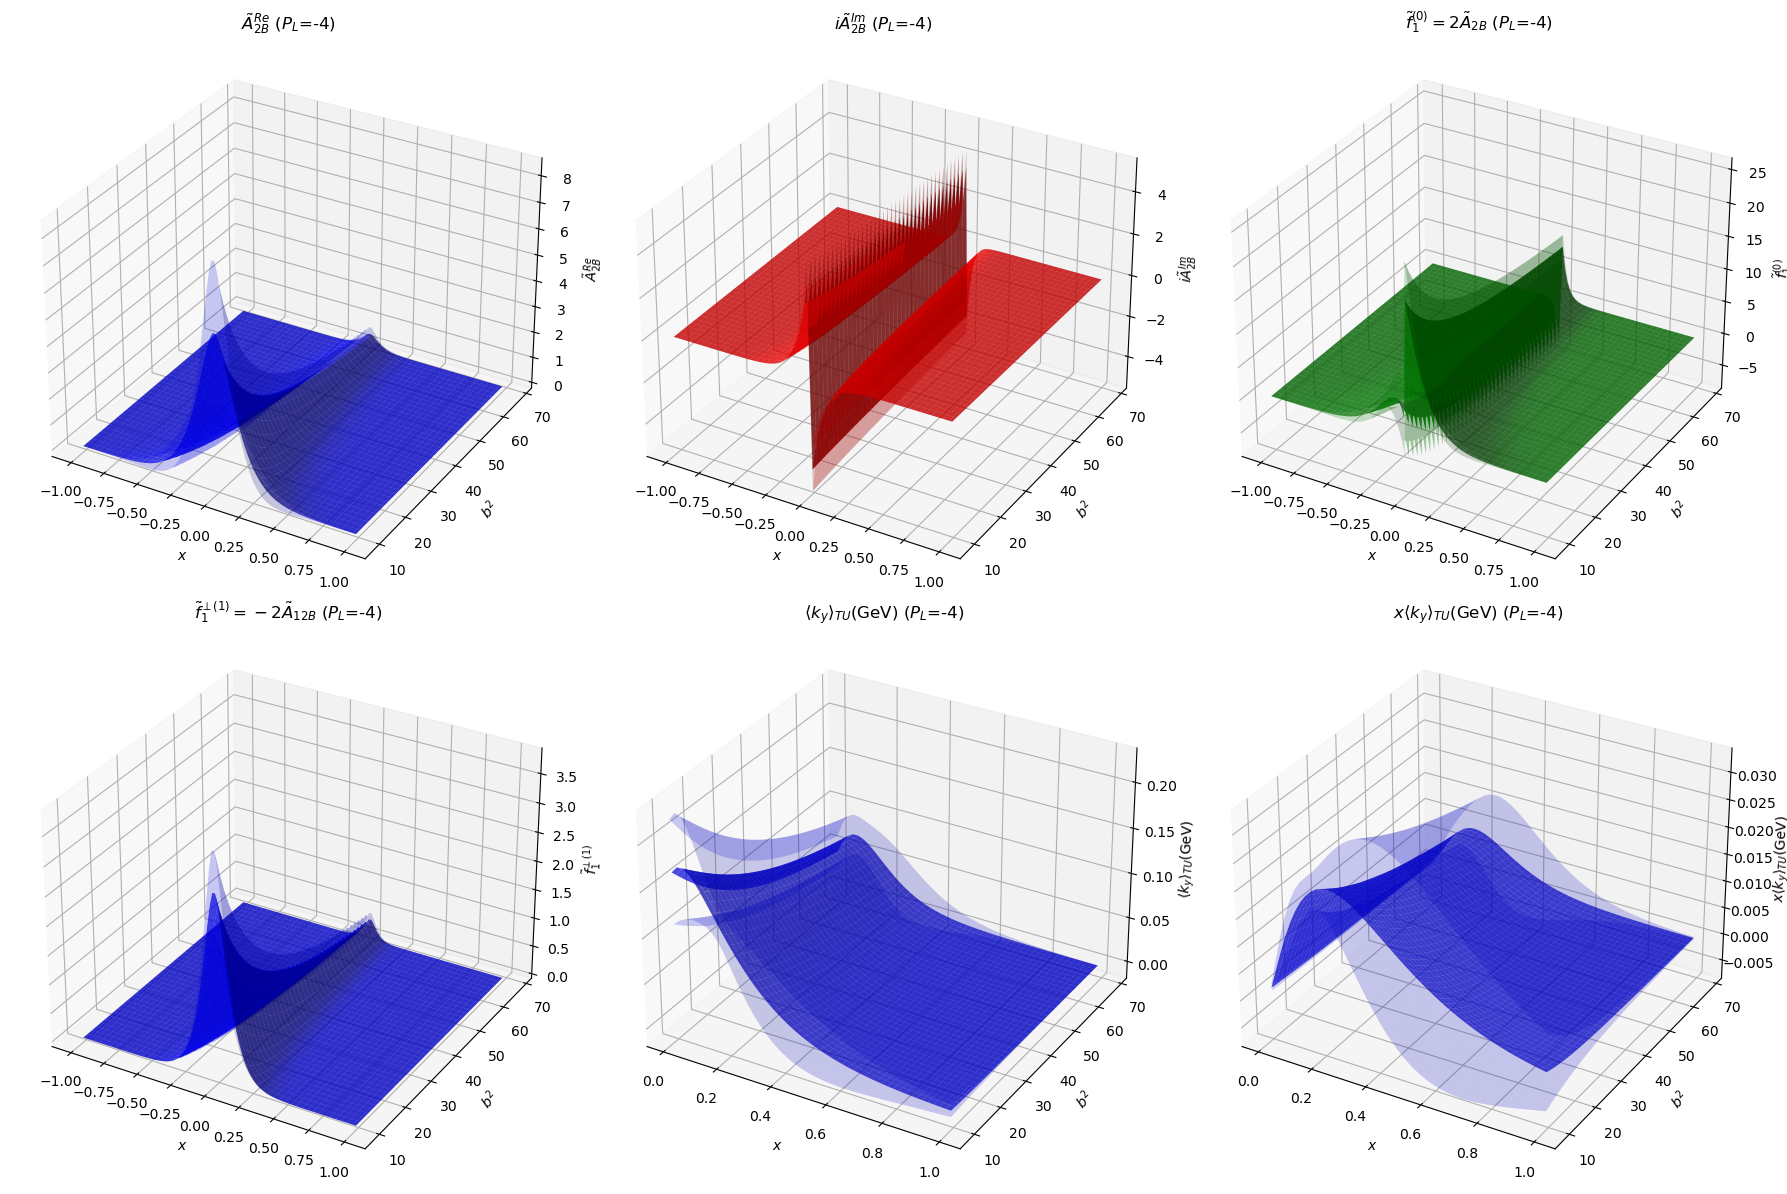

In [17]:
PL = -4
bminfit = 3
etamin = 6
etamax = 10
#sivers_TMD_PhD_project/save_h5_A12B_A2B/SimultaniousFit/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin3_eta610_PL-4.h5
fitted_params, chi2_dof_list = load_params_from_h5(f"/Users/hariprashadravikumar/sivers_TMD_PhD_project/save_h5_A12B_A2B/SimultaniousFit/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.h5")
plot_fourier_transforms_3D(fitted_params, chi2_dof_list, PL, bminfit, etamin, etamax)



Evaluating discrete Fourier transforms over PL list for fixed b^2 = 9.0...


Evaluating PL slices:   0%|          | 0/4 [00:00<?, ?it/s]

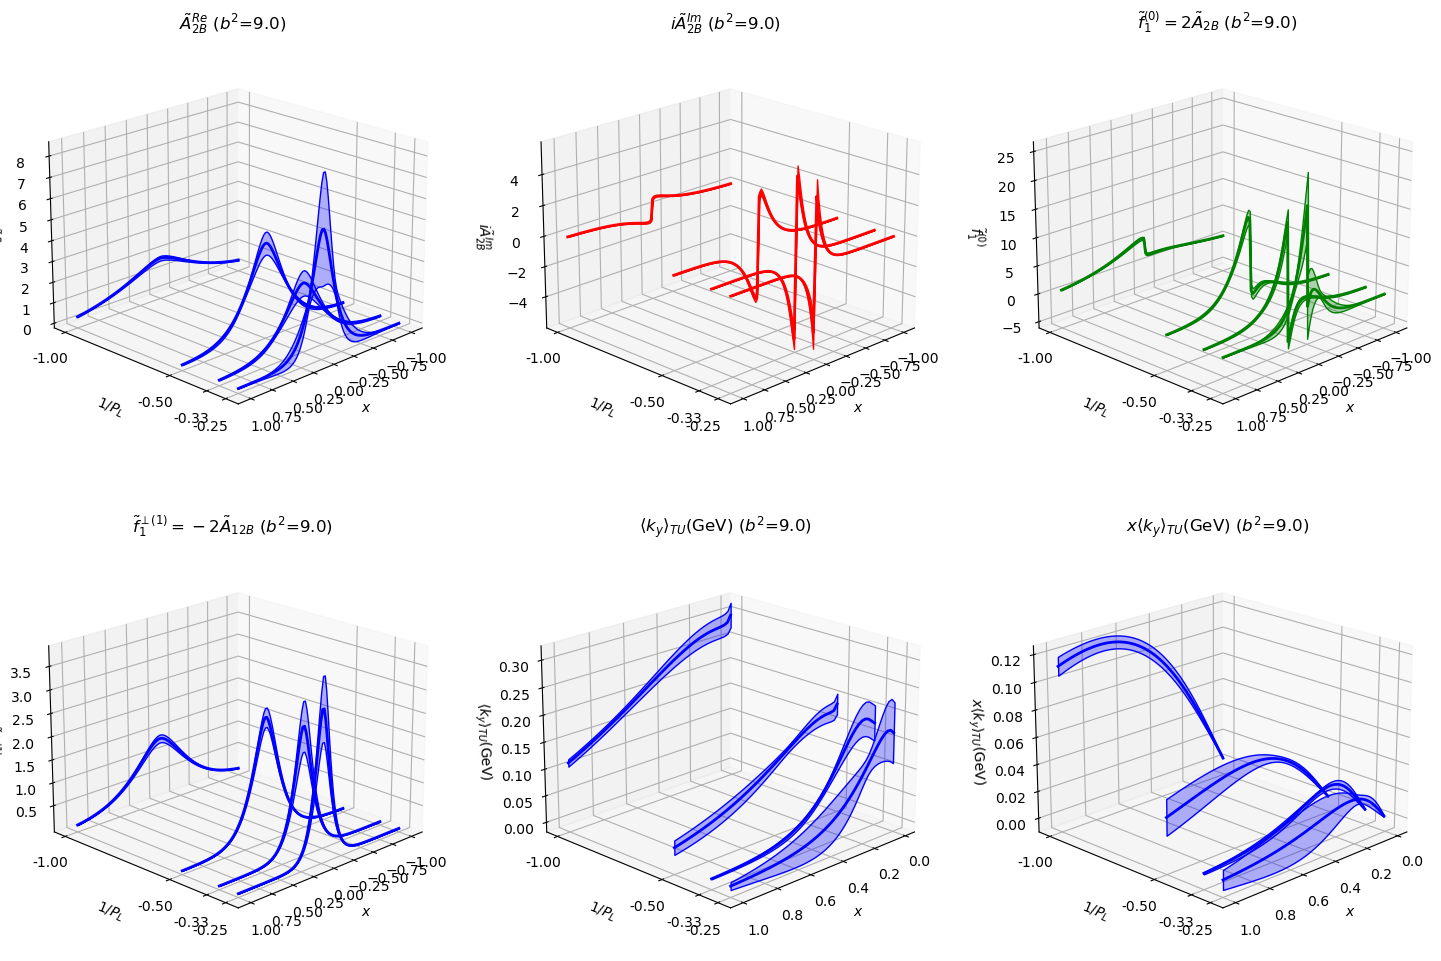

In [4]:
import h5py
import numpy as np
import math
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.special import kv, gamma

# ---------------------------------------------------------
# 1. Jackknife Statistics Helper
# ---------------------------------------------------------
def Jackknife(datalist): 
    N = len(datalist)
    theta_bar = np.mean(datalist)
    theta_nminus_theta_bar = []
    for i in range(N): 
        theta_n = datalist[i]
        theta_nminus_theta_bar.append(np.square(theta_n - theta_bar))
    sigma_sq = ((N-1)/N) * np.sum(theta_nminus_theta_bar)
    return theta_bar, np.sqrt(sigma_sq)

def load_params_from_h5(filename):
    fitted_params = {}
    with h5py.File(filename, "r") as f:
        # Load the jackknifed parameter samples
        param_group = f["jackknife_samples"]
        for key in param_group.keys():
            fitted_params[key] = param_group[key][:]
            
        # Load the chi-square per dof array
        chi2_dof_list = f["chi2_dof"][:]
        
    return fitted_params, chi2_dof_list

# ---------------------------------------------------------
# 2. 3D Plotting Function (Distinct Slices for 1/PL)
# ---------------------------------------------------------
def plot_fourier_transforms_3D_PL_discrete(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=100):
    
    # 1. Setup X (x-values)
    x_vals = np.linspace(-1, 1, num_points_x)
    
    MassN = 0.6228
    lata = 0.11403
    massterm = MassN * (197 * 0.001 / lata)
    
    # Calculate 1/PL and sort them
    inv_PL_vals = np.array([1.0 / pl for pl in PL_list])
    sort_idx = np.argsort(inv_PL_vals)
    inv_PL_vals = inv_PL_vals[sort_idx]
    sorted_PL_list = [PL_list[i] for i in sort_idx]

    # Initialize figure
    fig = plt.figure(figsize=(18, 12))
    ax1 = fig.add_subplot(231, projection='3d')
    ax2 = fig.add_subplot(232, projection='3d')
    ax3 = fig.add_subplot(233, projection='3d')
    ax4 = fig.add_subplot(234, projection='3d')
    ax5 = fig.add_subplot(235, projection='3d')
    ax6 = fig.add_subplot(236, projection='3d')
    
    axes = [ax1, ax2, ax3, ax4, ax5, ax6]

    # Helper function to plot a discrete 3D slice (line + vertical error band)
    def add_discrete_3d_band(ax, x, y_val, mean, err, color):
        # Plot the central mean line
        ax.plot(x, [y_val]*len(x), mean, color=color, linewidth=2)
        
        # Create a vertical polygon for the error band
        x_poly = np.concatenate([x, x[::-1]])
        y_poly = np.full_like(x_poly, y_val)
        z_poly = np.concatenate([mean - err, (mean + err)[::-1]])
        
        # Add polygon to axes
        verts = [list(zip(x_poly, y_poly, z_poly))]
        poly = Poly3DCollection(verts, color=color, alpha=0.3)
        ax.add_collection3d(poly)
        
        # Update limits manually since add_collection3d doesn't auto-scale Z
        ax.auto_scale_xyz(x, [y_val]*len(x), z_poly, had_data=True)

    print(f"\nEvaluating discrete Fourier transforms over PL list for fixed b^2 = {b2}...")
    
    # Loop over PL
    for i, pl in enumerate(tqdm(sorted_PL_list, desc="Evaluating PL slices")):
        
        y_val = 1.0 / pl
        
        # Dynamically load the data for the current PL
        filename = f"/Users/hariprashadravikumar/sivers_TMD_PhD_project/save_h5_A12B_A2B/SimultaniousFit/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{pl}.h5"
        fitted_params, _ = load_params_from_h5(filename)
        
        # Extract parameters specifically scaled for this PL
        a_re = np.array(fitted_params['a_re'])
        c_re = np.array(fitted_params['c_re']) / (pl**2)
        j_re = np.array(fitted_params['j_re'])
        d_re = 1.0 + np.array(fitted_params['d_re']) * b2  

        a_im = np.array(fitted_params['a_im']) / pl
        c_im = np.array(fitted_params['c_im']) / (pl**2)
        j_im = np.array(fitted_params['j_im'])
        d_im = 1.0 + np.array(fitted_params['d_im']) * b2

        a_reA12B = -np.array(fitted_params['a_reA12B'])
        c_reA12B = np.array(fitted_params['c_reA12B']) / (pl**2)
        j_reA12B = np.array(fitted_params['j_reA12B'])
        d_reA12B = 1.0 + np.array(fitted_params['d_reA12B']) * b2
        
        # Initialize arrays for this specific slice
        re_m, re_e = np.zeros_like(x_vals), np.zeros_like(x_vals)
        im_m, im_e = np.zeros_like(x_vals), np.zeros_like(x_vals)
        full_m, full_e = np.zeros_like(x_vals), np.zeros_like(x_vals)
        reA12B_m, reA12B_e = np.zeros_like(x_vals), np.zeros_like(x_vals)
        siv_m, siv_e = np.zeros_like(x_vals), np.zeros_like(x_vals)
        xsiv_m, xsiv_e = np.zeros_like(x_vals), np.zeros_like(x_vals)
        
        # Evaluate for each x
        for j, x in enumerate(x_vals):
            abs_x = max(np.abs(x), 1e-12)
            safe_x = x if x != 0 else 1e-12

            # --- Evaluate Real Part ---
            cd_R = c_re / d_re
            term1_R = (2**(1 - j_re) * a_re * cd_R**(-0.25 - j_re/2) * d_re**(-j_re)) / gamma(j_re)
            term2_R = abs_x**(-0.5 + j_re)
            bessel_R = kv(0.5 - j_re, abs_x / np.sqrt(cd_R))
            re_evals = term1_R * term2_R * bessel_R
            re_m[j], re_e[j] = Jackknife(re_evals)

            # --- Evaluate Imaginary Part ---
            cd_I = c_im / d_im
            term1_I = (2**(1 - j_im) * a_im * cd_I**(0.25 * (-3 - 2*j_im)) * d_im**(-j_im)) / gamma(j_im)
            term2_I = safe_x * abs_x**(-1.5 + j_im)
            bessel_I = kv(1.5 - j_im, np.sqrt(d_im / c_im) * abs_x)
            im_evals = term1_I * term2_I * bessel_I
            im_m[j], im_e[j] = Jackknife(im_evals)

            # --- Full A2B ---
            full_m[j], full_e[j] = Jackknife(2*(re_evals - im_evals))

            # --- Evaluate ReA12B Part ---
            cd_RA12B = c_reA12B / d_reA12B
            term1_RA12B = (2**(1 - j_reA12B) * a_reA12B * cd_RA12B**(-0.25 - j_reA12B/2) * d_reA12B**(-j_reA12B)) / gamma(j_reA12B)
            term2_RA12B = abs_x**(-0.5 + j_reA12B)
            bessel_RA12B = kv(0.5 - j_reA12B, abs_x / np.sqrt(cd_RA12B))
            reA12B_evals = term1_RA12B * term2_RA12B * bessel_RA12B
            reA12B_m[j], reA12B_e[j] = Jackknife(-2*reA12B_evals)

            # --- Sivers Shift ---
            siv_evals = (-massterm * reA12B_evals) / (re_evals - im_evals)
            siv_m[j], siv_e[j] = Jackknife(siv_evals)
            xsiv_m[j], xsiv_e[j] = Jackknife(safe_x * siv_evals)

        # Draw the slices onto the subplots
        add_discrete_3d_band(ax1, x_vals, y_val, re_m, re_e, 'blue')
        add_discrete_3d_band(ax2, x_vals, y_val, im_m, im_e, 'red')
        add_discrete_3d_band(ax3, x_vals, y_val, full_m, full_e, 'green')
        add_discrete_3d_band(ax4, x_vals, y_val, reA12B_m, reA12B_e, 'blue')

        # Sivers shift plots (Masked for x >= 0)
        mask = x_vals >= 0
        x_pos = x_vals[mask]
        add_discrete_3d_band(ax5, x_pos, y_val, siv_m[mask], siv_e[mask], 'blue')
        add_discrete_3d_band(ax6, x_pos, y_val, xsiv_m[mask], xsiv_e[mask], 'blue')

    # ---------------------------------------------------------
    # 3. Apply Formatting & Labels to all subplots
    # ---------------------------------------------------------
    titles = [
        f'$\\tilde{{A}}_{{2B}}^{{Re}}$ ($b^2$={b2})',
        f'$i\\tilde{{A}}_{{2B}}^{{Im}}$ ($b^2$={b2})',
        f'$\\tilde{{f}}_{{1}}^{{(0)}}=2\\tilde{{A}}_{{2B}}$ ($b^2$={b2})',
        f'$\\tilde{{f}}_{{1}}^{{\\perp(1)}}=-2\\tilde{{A}}_{{12B}}$ ($b^2$={b2})',
        f'$\\langle k_{{y}} \\rangle_{{TU}}$(GeV) ($b^2$={b2})',
        f'$x\\langle k_{{y}} \\rangle_{{TU}}$(GeV) ($b^2$={b2})'
    ]
    
    zlabels = [
        '$\\tilde{A}_{2B}^{Re}$', '$i\\tilde{A}_{2B}^{Im}$', '$\\tilde{f}_{1}^{(0)}$',
        '$\\tilde{f}_{1}^{\\perp(1)}$', '$\\langle k_{y} \\rangle_{TU}$(GeV)', '$x\\langle k_{y} \\rangle_{TU}$(GeV)'
    ]

    for idx, ax in enumerate(axes):
        ax.set_title(titles[idx])
        ax.set_xlabel('$x$')
        ax.set_ylabel('$1/P_L$')
        ax.set_zlabel(zlabels[idx])
        
        # Enforce strict discrete ticks on the Y-axis so only exact 1/PL values appear
        ax.set_yticks(inv_PL_vals)
        ax.set_yticklabels([f"{v:.2f}" for v in inv_PL_vals])
        ax.view_init(elev=20, azim=45)

    #plt.tight_layout()
    file_name = f"SimulFit_Distinct_1_over_PL_bmin{bminfit}_eta{etamin}{etamax}_b2{b2}.pdf"
    plt.savefig(file_name, format='pdf', bbox_inches='tight')
    plt.show()

# ---------------------------------------------------------
# Example Execution Call
# ---------------------------------------------------------
bminfit = 3
etamin = 6
etamax = 10
PL_list = [-1, -2, -3, -4]

# Execute the plot
plot_fourier_transforms_3D_PL_discrete(PL_list, bminfit, etamin, etamax, b2=9.0)